In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pd.set_option('display.max_columns', None)

# Read and pre-process data

In [3]:
train_data_path = "../data/datahow_interview_train_data.csv"
train_targets_data_path = "../data/datahow_interview_train_targets.csv"

In [4]:
train_df = pd.read_csv(train_data_path)
targets_df = pd.read_csv(train_targets_data_path)

In [5]:
# Drop RowID column
train_df = train_df.drop(columns="RowID")
targets_df = targets_df.drop(columns="RowID")

In [6]:
df = pd.merge(train_df, targets_df, how="outer", on=["Exp", "Time[day]"])

In [7]:
df.head()

,Exp,Time[day],Z:FeedStart,Z:FeedEnd,Z:FeedRateGlc,Z:FeedRateGln,Z:phStart,Z:phEnd,Z:phShift,Z:tempStart,Z:tempEnd,Z:tempShift,Z:Stir,Z:DO,Z:ExpDuration,W:temp,W:pH,W:FeedGlc,W:FeedGln,X:VCD,X:Glc,X:Gln,X:Amm,X:Lac,X:Lysed,Y:Titer
0,Exp 1,0,2.0,10.0,5.656566,6.818182,6.808081,6.479798,9.0,37.282828,35.070707,13.0,224.242424,43.383838,10.0,37.282828,6.808081,0.000000,0.000000,1.682644,2.853045,6.005418,0.100000,0.100000,0.000000,NaN
1,Exp 1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.282828,6.808081,0.000000,0.000000,3.617721,2.290199,3.598475,0.324724,1.348831,0.002831,NaN
2,Exp 1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.282828,6.808081,5.656566,6.818182,6.431879,0.752652,0.481756,0.687781,3.065268,0.000884,NaN
3,Exp 1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.282828,6.808081,5.656566,6.818182,10.279057,4.276583,2.516062,0.972871,4.196027,0.000000,NaN
4,Exp 1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.282828,6.808081,5.656566,6.818182,14.888965,7.350100,3.471558,1.322927,4.845310,0.000218,NaN


# Plots

In [8]:
z_cols = [col for col in train_df.columns if col.startswith("Z:")]
w_cols = [c for c in df.columns if c.startswith("W:")]
x_cols = [c for c in df.columns if c.startswith("X:")]

In [9]:
df_exp = df.query("Exp == 'Exp 10'")

## Single experiment view
Time-series view of a single experiment, grouped by prefix into rows.  

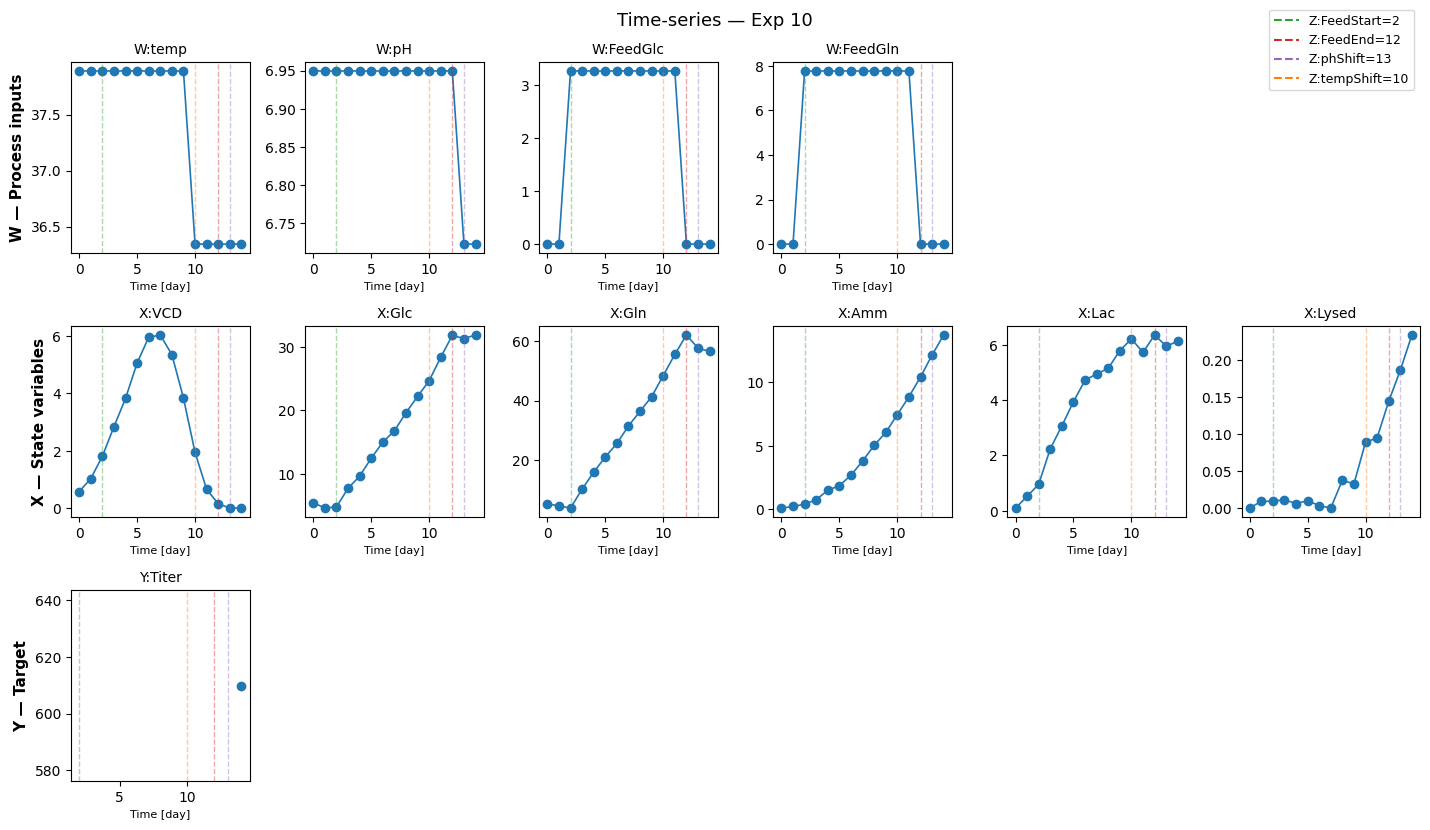

In [10]:
groups = [
    ("W — Process inputs", [c for c in df.columns if c.startswith("W:")]),
    ("X — State variables", [c for c in df.columns if c.startswith("X:")]),
    ("Y — Target", [c for c in df.columns if c.startswith("Y:")]),
]

setpoints = df_exp.loc[df_exp["Time[day]"] == 0].iloc[0]
event_colors = {
    "FeedStart": "tab:green",
    "FeedEnd":   "tab:red",
    "phShift":   "tab:purple",
    "tempShift": "tab:orange",
}
events = {
    name: setpoints[f"Z:{name}"]
    for name in event_colors
    if 0 <= setpoints[f"Z:{name}"] <= setpoints["Z:ExpDuration"]
}

n_cols = max(len(cols) for _, cols in groups)
fig, axes = plt.subplots(
    nrows=len(groups), ncols=n_cols,
    figsize=(2.4 * n_cols, 2.8 * len(groups)),
    squeeze=False,
)

for row, (group_name, cols) in enumerate(groups):
    for c in range(n_cols):
        ax = axes[row, c]
        if c < len(cols):
            col = cols[c]
            data = df_exp[["Time[day]", col]].dropna()
            ax.plot(data["Time[day]"], data[col], marker="o", linewidth=1.2)
            ax.set_title(col, fontsize=10)
            ax.set_xlabel("Time [day]", fontsize=8)
            for name, day in events.items():
                ax.axvline(day, linestyle="--", color=event_colors[name],
                           alpha=0.4, linewidth=1)
        else:
            ax.axis("off")
    axes[row, 0].set_ylabel(group_name, fontsize=11, fontweight="bold")

legend_handles = [
    plt.Line2D([0], [0], color=event_colors[k], linestyle="--",
               label=f"Z:{k}={int(events[k])}")
    for k in events
]
fig.legend(handles=legend_handles, loc="upper right",
           bbox_to_anchor=(0.99, 0.99), fontsize=9)
fig.suptitle(f"Time-series — {df_exp['Exp'].iloc[0]}", fontsize=13)

plt.tight_layout()

## Per-experiment distributions

Text(0.5, 0.98, 'Per-experiment distributions: target & setpoints')

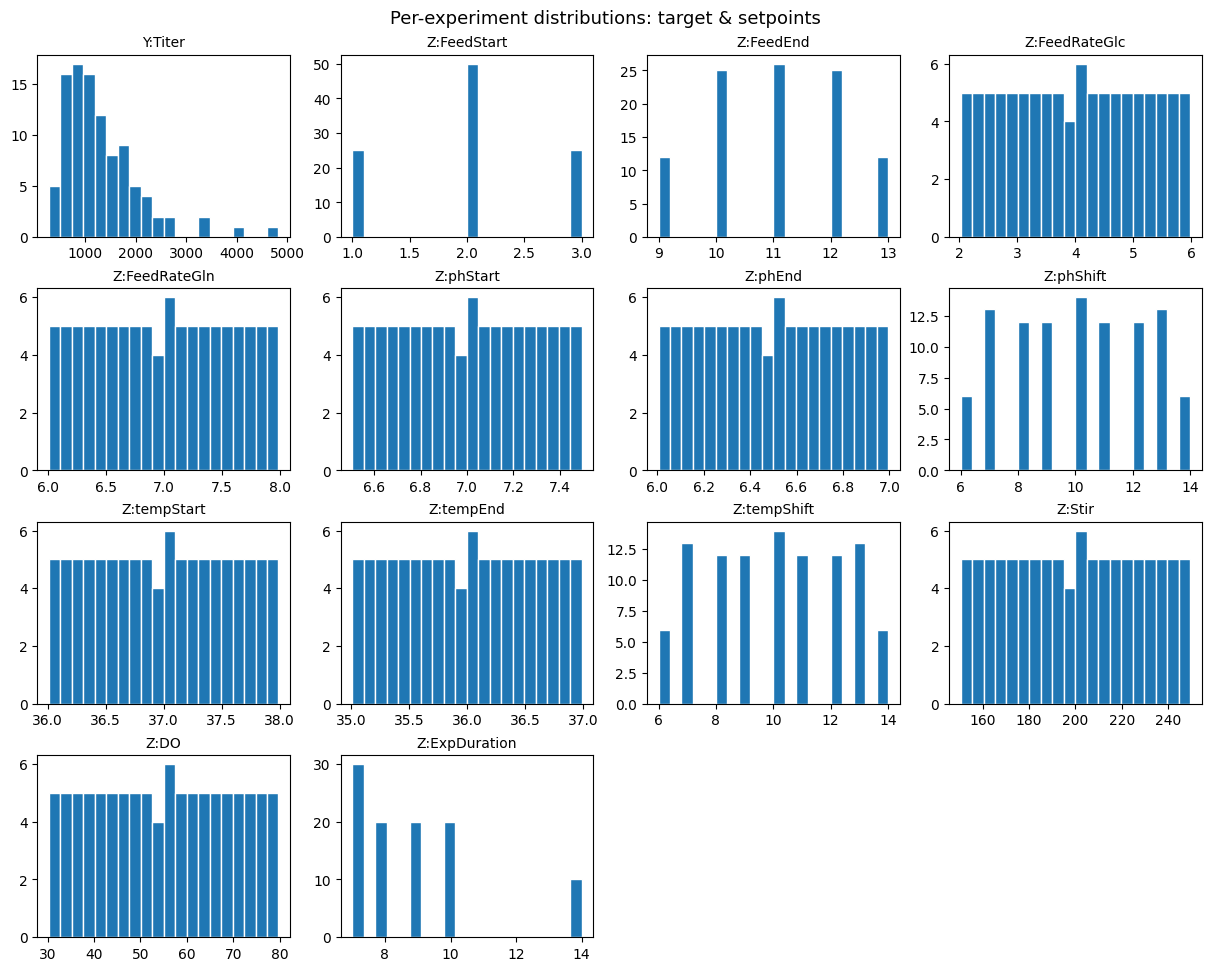

In [17]:
titer_by_exp = df.dropna(subset=["Y:Titer"]).set_index("Exp")["Y:Titer"]

exp_level = (
    df.query("`Time[day]` == 0")[["Exp"] + z_cols]
    .set_index("Exp")
    .join(titer_by_exp.rename("Y:Titer"))
)

cols_to_plot = ["Y:Titer"] + z_cols
ncols = 4
nrows = (len(cols_to_plot) + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows, ncols, figsize=(3.0 * ncols, 2.4 * nrows), constrained_layout=True
)
axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    ax.hist(exp_level[col], bins=20, edgecolor="white")
    ax.set_title(col, fontsize=10)

for ax in axes[len(cols_to_plot):]:
    ax.axis("off")

fig.suptitle("Per-experiment distributions: target & setpoints", fontsize=13)

## Y:Titer vs. log(Y:Titer)
Comparing the raw and log-transformed target distributions to decide whether to model `Y:Titer` directly or its log.  
The titer raw distribution looks right-skewed, which biases regression losses toward the high-titer tail; a log transform should pull the distribution closer to symmetric and make squared-error losses better behaved.

Text(0.5, 0.98, 'Distribution of final titer - raw vs. log')

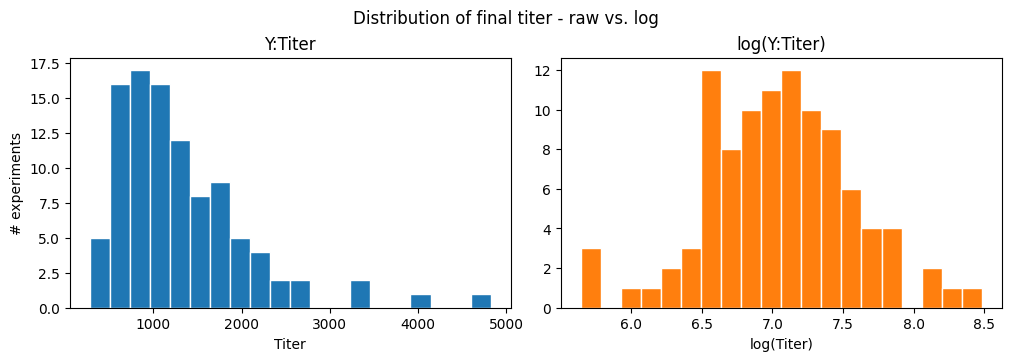

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)

# Raw
axes[0].hist(titer_by_exp, bins=20, edgecolor="white")
axes[0].set_title("Y:Titer")
axes[0].set_xlabel("Titer")
axes[0].set_ylabel("# experiments")

# Log
axes[1].hist(np.log(titer_by_exp), bins=20, edgecolor="white", color="tab:orange")
axes[1].set_title("log(Y:Titer)")
axes[1].set_xlabel("log(Titer)")

fig.suptitle("Distribution of final titer - raw vs. log", fontsize=12)

**Conclusion.** Modeling `log(Y:Titer)` is the better choice: the raw titer is clearly right-skewed, while the log-transformed version is close to a bell shape.  
We'll train against `log(Y:Titer)` and exponentiate at prediction time.

## Univariate correlation sweep
Identify which raw columns and which time-series summaries carry the strongest univariate signal against `log(Y:Titer)`. We build one feature per experiment from each column, scatter it against `log(Y:Titer)`, and annotate the Pearson correlation. Panels are sorted by `|r|` so the strongest correlates surface first.

Per-group transformations:
- **`Z:` setpoints.** Used as-is (one constant value per experiment).
- **`W:` process inputs.** Aggregated across the run as `sum` (total dosed/applied) and `mean` (average level).
- **`X:` state variables.** Summarized with `final` (last-day value), `max` (peak), `mean` (overall level), `AUC` (time-integrated exposure), and `slope` (linear trend over time).

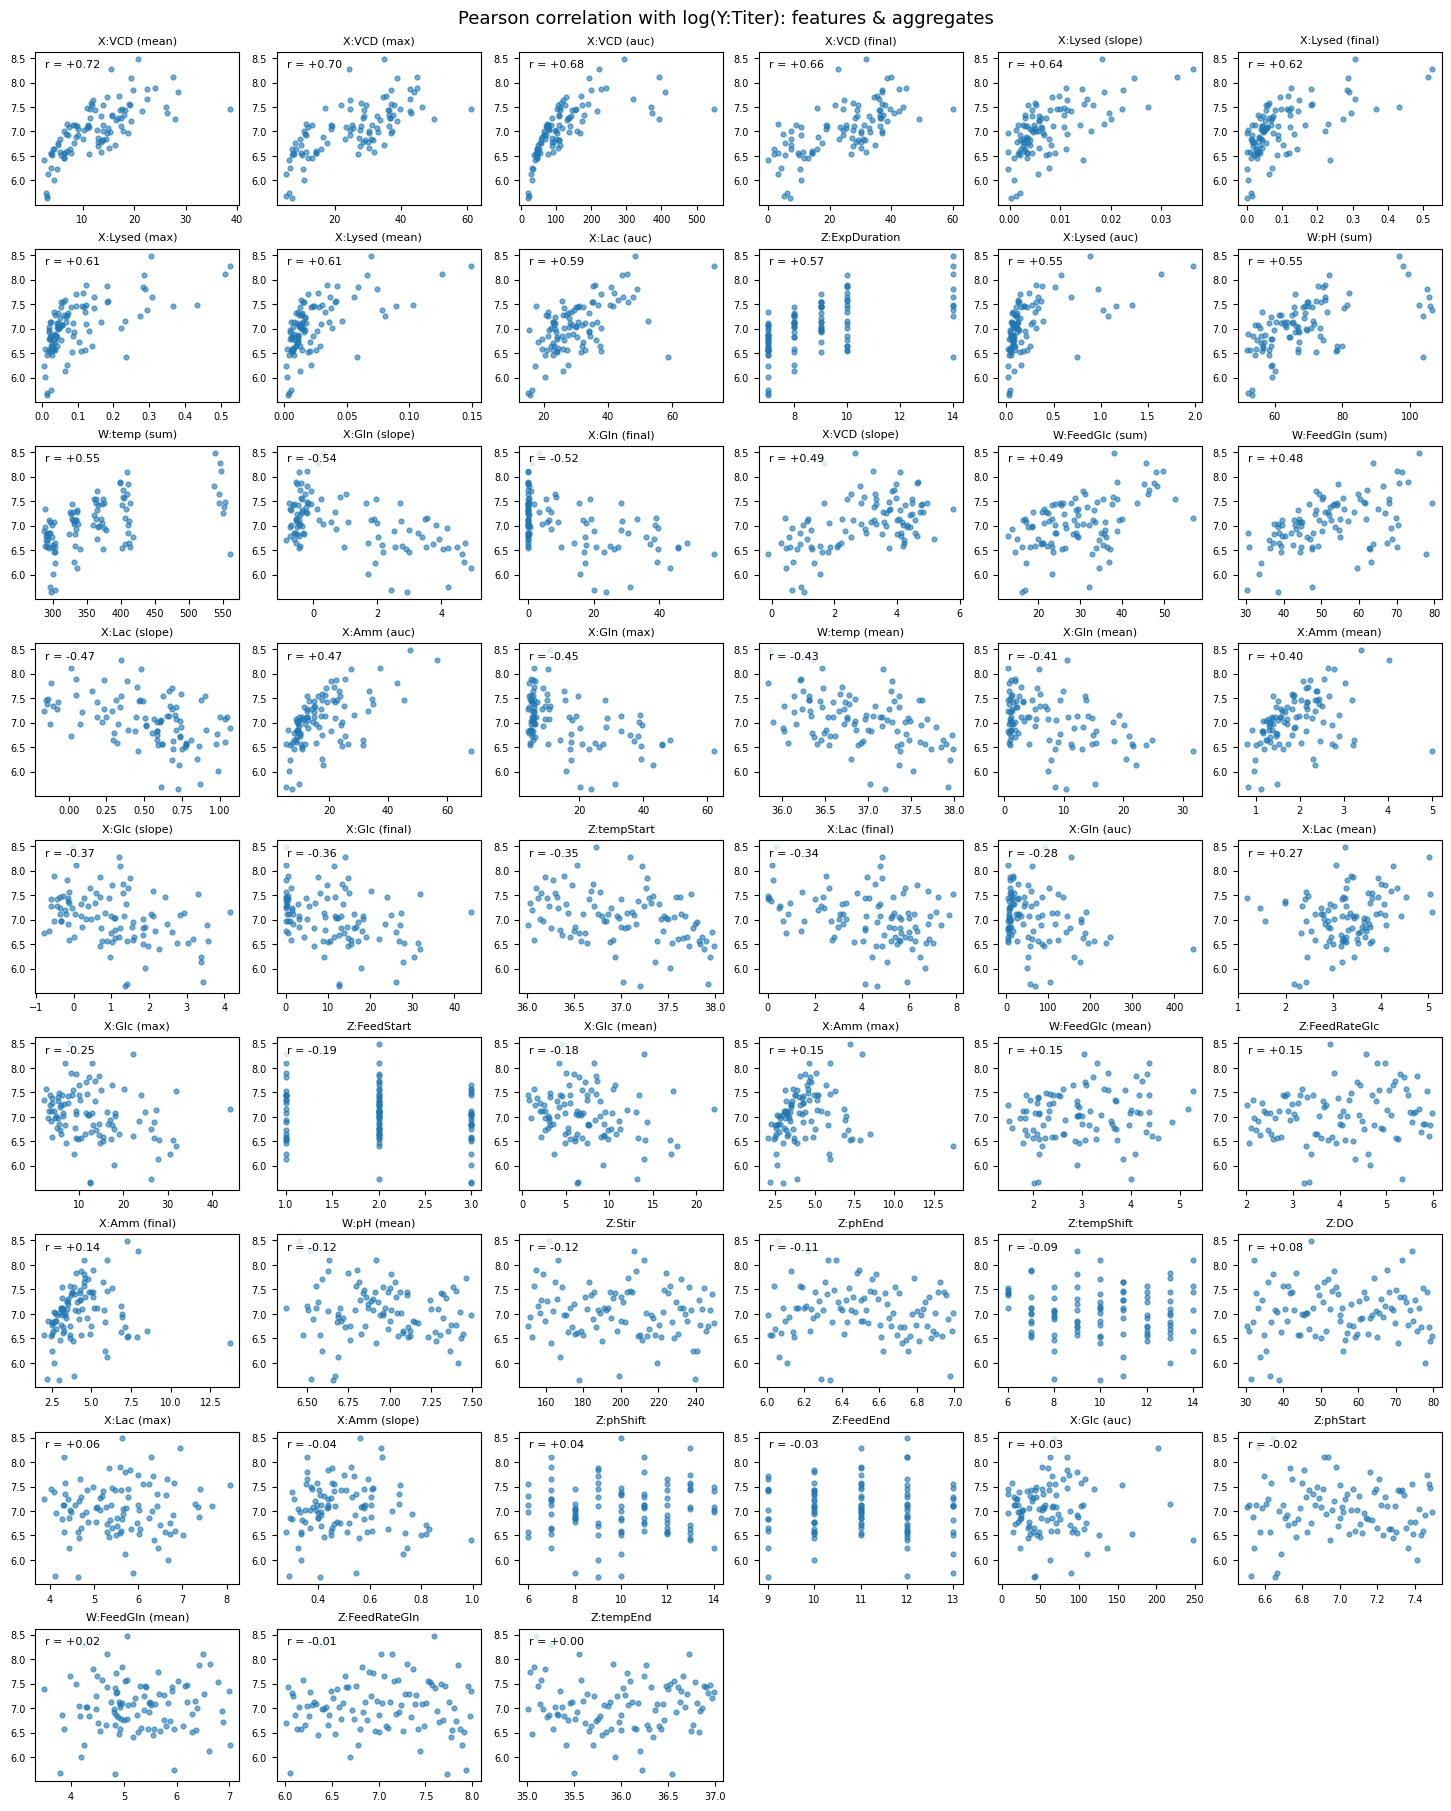

In [14]:
rows = []
for exp, exp_df in df.groupby("Exp"):
    exp_df = exp_df.sort_values("Time[day]")
    time = exp_df["Time[day]"].values
    day0 = exp_df.loc[exp_df["Time[day]"] == 0].iloc[0]

    row = {"Exp": exp}
    for col in z_cols:
        row[col] = day0[col]

    for col in w_cols:
        row[f"{col} (sum)"] = exp_df[col].sum()
        row[f"{col} (mean)"] = exp_df[col].mean()

    for col in x_cols:
        s = exp_df[col].values
        row[f"{col} (final)"] = s[-1]
        row[f"{col} (max)"] = s.max()
        row[f"{col} (mean)"] = s.mean()
        row[f"{col} (auc)"] = np.trapezoid(s, time)
        row[f"{col} (slope)"] = np.polyfit(time, s, 1)[0]

    rows.append(row)

features = pd.DataFrame(rows).set_index("Exp")
log_titer = np.log(titer_by_exp.loc[features.index])

corrs = features.apply(lambda c: np.corrcoef(c, log_titer)[0, 1])
ordered = corrs.abs().sort_values(ascending=False).index

ncols = 6
nrows = (len(ordered) + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows, ncols, figsize=(2.4 * ncols, 2.0 * nrows), constrained_layout=True
)
axes = axes.flatten()

for ax, col in zip(axes, ordered):
    ax.scatter(features[col], log_titer, alpha=0.6, s=12)
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.text(
        0.05, 0.95, f"r = {corrs[col]:+.2f}",
        transform=ax.transAxes, va="top", fontsize=8,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
    )

for ax in axes[len(ordered):]:
    ax.axis("off")

fig.suptitle("Pearson correlation with log(Y:Titer): features & aggregates", fontsize=13)
plt.show()

## Top correlate: mean X:VCD vs. log(Y:Titer)
The sweep above ranks `X:VCD (mean)` as the single strongest univariate predictor of `log(Y:Titer)`: its Pearson `|r|` is the largest of any feature/aggregate considered.  
This makes physical sense: a higher average viable cell density across the run means more producer cells contributing to titer over the entire experiment, not just at harvest.  
We isolate that scatter here for a closer look.

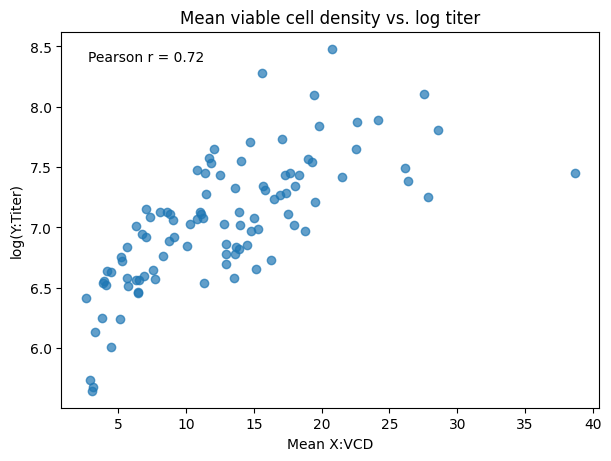

In [15]:
vcd_mean = df.groupby("Exp")["X:VCD"].mean()
log_titer = np.log(titer_by_exp.loc[vcd_mean.index])

fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
ax.scatter(vcd_mean, log_titer, alpha=0.7)
ax.set_xlabel("Mean X:VCD")
ax.set_ylabel("log(Y:Titer)")
ax.set_title("Mean viable cell density vs. log titer")

r = np.corrcoef(vcd_mean, log_titer)[0, 1]
ax.text(
    0.05, 0.95, f"Pearson r = {r:.2f}",
    transform=ax.transAxes, va="top", fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
)
plt.show()